**Lab 6: IIR Filtering**


The objective for this lab is to help you understand the relationship between the location
of poles and zeros in the z-domain, the impulse response h[n] in the n-domain, and the frequency
response $H(e^{j\omega})$. We use the system function,
represented as a ratio of polynomials in $z^{-1}$, which can be expressed in either factored or expanded form as:

$$
H(z) = G\frac{\prod_{k=1}^M (1-z_kz^{-1}) }{\prod_{k=1}^N (1-p_kz^{-1})} = \frac{ \sum_{k=0}^M b_kz^{-k}}{ 1- \sum_{k=1}^N a_kz^{-k} }
$$

In [1]:
import numpy as np
import IPython.display as ipd
from scipy import signal
import matplotlib.pyplot as plt

from util import load_audio, plot_signals, plot_spectrogram, plot_frequency_response

**1. IIR filters to extract the envelope**

In the previous labs, you extracted the envelope from your reference signal by applying the following system:

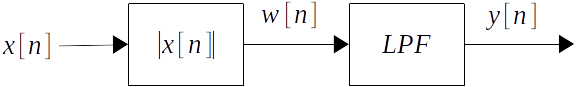

where $w[n] = |x[n]|$ and $y[n]$ was the output of a low-pass FIR filter (averaging filter). In this exercise, you will re-implement this low-pass filter as an IIR.

1.1 First, copy the functions envelope and synthesize from previous work and obtain the same synthesis. 



In [2]:
# Write your code here
ref, fs = load_audio('edited_audiowav.wav')

duration = 1.0
f0 = 248
phi = 3 * np.pi/2
Ak = [1, 0.803, 0.408, 0.313, 0.089, 0.065]  
t = np.arange(0, duration, 1/fs)
t_start = 0.335
t_end = 0.358

def synthesize(f0, phi, Ak, t):
  y = 0
  for k in range(1, len(Ak) + 1):
    y += Ak[k-1] * np.cos(2*np.pi*k*f0*t + k*phi - (k-1)*np.pi/2)
  return y

def envelope(x, N):
    rectified = np.abs(x)
    b = [1.0 / N for i in range(N)]
    y = np.convolve(rectified, b, mode='same')

    return y

synth = synthesize(f0, phi, Ak, t)

synth = 0.1 * synth / np.max(np.abs(synth)) 

N = 500
env = envelope(ref, N)
env = env[:len(synth)] 
synth_env = synth * env

t_start = 0.335
t_end = 0.358


1.2 Let's take a look at the following system:

$$
H(z) = G\frac{1+z^{-1}}{1-rz^{-1}} \quad   0<r<1 \quad, G = \frac{1-r}{2}
$$

Note that the coefficients of the filter are the following:

$$
b_0 = 1, \quad b_1 = 1, \quad a_0 = 1, \quad a_1 = -r, \quad
$$

i. Find the zeros and poles of the system analytically.

To find the zeros, we set the numerator B(z) = 1 + z^-1 equal to zero, which gives 1 + z^-1 = 0 --> z = -1. To find the poles, we set the denominator A(z) = 1 - rz^-1 equal to zero, yielding 1 - rz^-1 = 0 --> z = r. Therefore, the system has a single zero at z = -1 and a single pole at z = r.


ii. Use the function `np.roots` to find the zeros and poles using Python. Compare the results with part i.

In [6]:
# Write your code here

b = [1, 1]   # numerator coefficients
a = [1, - 0.8]  # denominator coefficients, for example r = 0.8

zeros = np.roots(b)
poles = np.roots(a)

print("Zeros:", zeros)
print("Poles:", poles)


Zeros: [-1.]
Poles: [0.8]


iii. Use the function  `plot_zeros_poles(z, p)` to plot the zeros and poles found in ii.

In [19]:
from util import plot_zeros_poles

# Write your code here
r = 0.5 # we set a random valure to r
b = [1, 1]
a = [1, -r]

# compute zeros and poles
zeros = np.roots(b)
poles = np.roots(a)

# Plot zeros and poles
plot_zeros_poles(zeros, poles)


1.3 Let's see the frequency response of this filter:



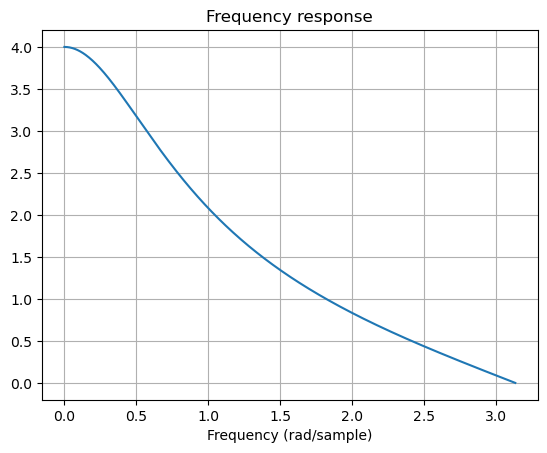

In [20]:
# Write your code here
from scipy.signal import freqz

w, h = freqz(b, a)

plt.plot(w, abs(h))
plt.xlabel("Frequency (rad/sample)")
plt.title("Frequency response")
plt.grid(True)
plt.show()

1.4. Change the parameter $r$ in the range $(0, 1)$. What happens when $r$ is increased?

When you increase r, the pole moves closer to the unit circle and the frequency response becomes more peaked at low frequencies

1.5 What type of filter is (low-pass, band-pass, or high-pass filter)?


This system is a low-pass filter. The pole at z = r increases the gain at low frequencies, while the zero at z = -1 reduces the gain at high frequencies. Because the response is strongest at low frequencies and gradually decreases as frequency increases, the overall behavior clearly matches that of a low-pass filter.


1.6 Now we can use this IIR filter to extract the envelope. Let's define a new function `envelope_iir(x)` that applies the filter to the absolute value of the signal. Note that we are using signal.lfilter function to apply the filter.


In [22]:
from scipy.signal import lfilter
def envelope_iir(x, r=0.995):
    b = [1, 1]
    a = [1, -r]
    return lfilter(b, a, np.abs(x))

Extract the envelope of your reference signal using both the FIR and IIR filters and compare the results plot them along with the signal. Change the value of $r$ until you are comfortable with the result.

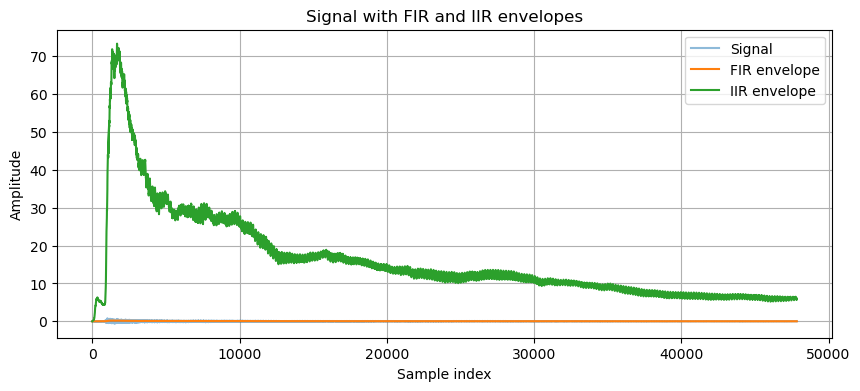

In [30]:
# Write your code here
def envelope_fir(x, M=200):
    b = np.ones(M) / M
    a = [1]
    return lfilter(b, a, np.abs(x))

env_fir = envelope_fir(ref)
env_iir = envelope_iir(ref, r=0.995) 

plt.figure(figsize=(10,4))
plt.plot(ref, label='Signal', alpha=0.5)
plt.plot(env_fir, label='FIR envelope', linewidth=1.5)
plt.plot(env_iir, label='IIR envelope', linewidth=1.5)
plt.legend()
plt.xlabel('Sample index')
plt.ylabel('Amplitude')
plt.title('Signal with FIR and IIR envelopes')
plt.grid(True)
plt.show()


1.7 What are the main differences between the two filters? For instance, compare the number of coefficients.

The FIR and IIR envelope detectors behave very differently. The FIR filter uses a fixed number of coefficients, equal to the window length M, so it has a short memory: after M samples, past values no longer affect the output. This produces a smooth but relatively flat envelope that reacts quickly and does not grow in amplitude. The IIR filter uses only two coefficients but has an extremely long memory because the feedback term keeps adding part of the previous output forever. As a result, the IIR envelope grows much larger, responds more slowly, and produces a smoother and more sustained shape.

1.8 Apply the new envelope (extracted from the IIR filter) to the synthesis generated with the `synthesize` function and listen to the result.

In [32]:
# Write your code here

env_iir_cut = env_iir[:len(synth)]

synth_iir = synth * env_iir_cut

max_val = np.max(np.abs(synth_iir))
synth_iir = synth_iir / max_val

ipd.Audio(synth_iir, rate=fs)


---

**2. Band-pass filters**

Now let's work with the following system: 

$$
H(z) = \frac{(1-z^{-1})(1+z^{-1})}{(1-re^{j\omega_n}z^{-1})(1-re^{-j\omega_n}z^{-1})}, \quad 0<r<1
$$

Note that the poles are $p_1 = re^{j\omega_n}$ and $p_2 = re^{-j\omega_n}$; and the zeros are $z_1=1$ and $z_2=-1$. 

2.1 Use the function `plot_zeros_poles` to plot the zeros and poles of the system.

Note: use $w_n = \pi/4$ and $r=0.99$.

In [33]:
# Write your code here

wn = np.pi / 4
r = 0.99

# Zeros
z1 = 1
z2 = -1
zeros = np.array([z1, z2])

# Poles
p1 = r * np.exp(1j * wn)
p2 = r * np.exp(-1j * wn)
poles = np.array([p1, p2])

# Plot
plot_zeros_poles(zeros, poles)


2.2 Show analytically that $a_k = [1, -2rcos(\omega_n), r^2]$ and $b_k=[1, 0, -1]$.

The coefficients ak and bk can be derived directly from the pole-zero locations of the filter. If the filter has poles at z = re ^ jw and z = re^ -jw, the denominator polynomial is A(z) = (1 - re^jw * z^-1)(1 - re^-jw * z^-1) = 1 - 2rcos(w)z^-1 + r^2 * z^-2, giving ak = [1, -2rcos(w), r^2]. Similarly, if the zeros are at z = 1 and -1, the numerator polynomial is B(z) = (1 - z^-1)(1 + z^-1) = 1 - z^-2, giving bk = [1, 0, -1]. Thus, the coefficients directly reflect the positions of the poles and zeros in the z-plane.

2.3 Plot the frequency response of the filter. Confirm this is a band-pass filter. What's the central frequency of the passband?

/var/folders/dl/t9tct74d1m36p593ft3tmhp80000gn/T/ipykernel_12632/4059700141.py:10: RuntimeWarning:

divide by zero encountered in log10



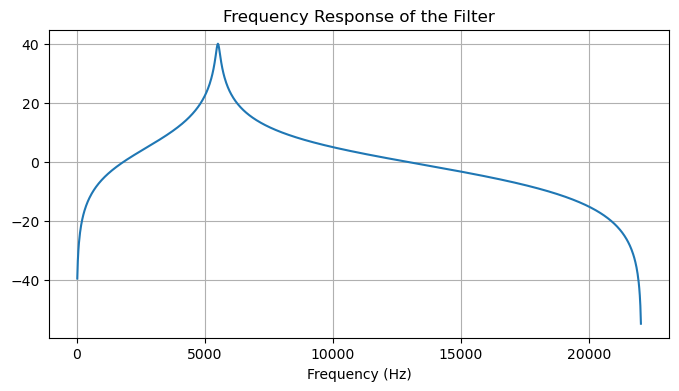

In [36]:

a = [1, -2*r*np.cos(wn), r**2]

b = [1, 0, -1]

w, h = freqz(b, a, worN=1024)  

f = w * fs / (2*np.pi)

plt.figure(figsize=(8,4))
plt.plot(f, 20*np.log10(np.abs(h)))
plt.title('Frequency Response of the Filter')
plt.xlabel('Frequency (Hz)')
plt.grid(True)
plt.show()


The frequency response of the filter shows that it passes a specific range of frequencies while attenuating frequencies outside this range, which confirms that it behaves as a band-pass filter. The magnitude is highest near the frequency corresponding to the angle of the poles, while frequencies much lower or higher are strongly reduced. By examining the response, the central frequency of the passband—the frequency at which the filter has its maximum gain which is approximately 5500 Hz.


2.4 Define a function `bpf(x, f, r, fs)` that applies the above band-pass filter. 

Note 1: remember that a frequency can be converted to the normalized radian frequncy by: $\omega_n = 2\pi f_n/f_s$.

Note 2: use `signal.lfilter` function to implement the filter.

In [37]:
def bpf(x, fn, fs, r=0.995):
      wn = 2 * np.pi * fn / fs

    # Denominator coefficients from poles
      a = [1, -2*r*np.cos(wn), r**2]

    # Numerator coefficients from zeros at +1 and -1
      b = [1, 0, -1]

    # Apply filter using lfilter
      y = lfilter(b, a, x)

      return y


2.5 Regardless of the phase, until now we were synthesizing the instrument signal by summing $K$ harmonics of the signal with different weights ($A_k$) and multiplying the sum by the envelope of the reference signal ($e(t)$):

$$y(t) = e(t) \cdot \sum_{k=1}^K A_k\cos\left(2\pi kf_0 t \right), $$

where $f_0$ is the fundamental frequency of the note. Now we want to improve this synthesis by finding a time-dependent amplitude ($A_k(t)$) for each harmonic:

$$y(t) = \sum_{k=1}^K A_k(t) \cos\left(2\pi kf_0 t \right), $$

where $A_k(t)$ is the amplitude of the harmonic $k$. To extract the amplitudes $A_k(t)$ we'll apply a band-pass filter with central frequency $kf_0$ and calculate the envelope of the output by using the `envelope_iir`.


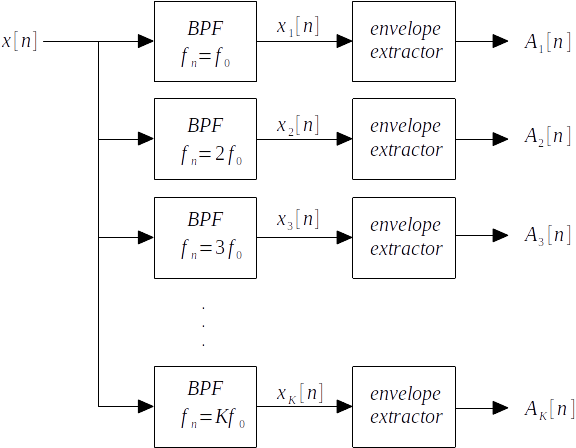

For instance, the following code should extract the envelope of the fundamental frequency component. Change the value of $f_0$ to coincide with your fundamental frequency and check the result. 

In [39]:
# Write your code here
K = len(Ak)
f0 = 248
Ak_t = np.zeros((K, len(ref)))
for k in range(1, K+1):
    filtered = bpf(ref, k*f0, fs, r=0.995)
    Ak_t[k-1, :] = envelope_iir(filtered, r=0.995)

synth_time_varying = np.zeros(len(ref))
t = np.arange(len(ref)) / fs
for k in range(1, K+1):
    synth_time_varying += Ak_t[k-1, :] * np.cos(2 * np.pi * k * f0 * t)

synth_time_varying = synth_time_varying / np.max(np.abs(synth_time_varying))

ipd.Audio(synth_time_varying, rate=fs)


2.6 Complete the `synthetize_with_bpf` function to implement a synthesis applying different envelopes for each harmonic.


In [40]:
def synthetize_with_bpf(x, f0, phi, K, fs):
    y = np.zeros(len(x))
    t = np.arange(len(x)) / fs
    for k in range(1, K+1):
        filtered = bpf(x, k*f0, fs, r=0.995)
        Ak_t = envelope_iir(filtered, r=0.995)
        y += Ak_t * np.cos(2 * np.pi * k * f0 * t + k*phi)
    y = y / np.max(np.abs(y))
    return y


2.6 Call the function `synthetize_with_bpf` to get the synthesized signal and **listen to it**.

Note that now you can increase the number of harmonics $K$ as you want because we are not manually measuring the weights of each harmonic.

In [51]:
# Write your code here
K = 10 
f0 = 248
phi = 3 * np.pi / 2

synth_bpf = synthetize_with_bpf(ref, f0, phi, K, fs)

ipd.Audio(synth_bpf, rate=fs)


2.7 Compare the **spectrograms** of the synthesized signal and reference signal.

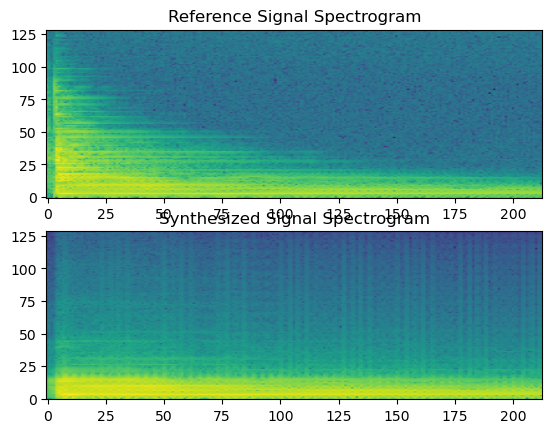

In [49]:
# Write your code here
from scipy.signal import spectrogram

f_ref, t_ref, S_ref = spectrogram(ref, fs)
f_syn, t_syn, S_syn = spectrogram(synth_bpf, fs)

plt.figure()
plt.subplot(2,1,1)
plt.imshow(20*np.log10(S_ref), aspect='auto', origin='lower')
plt.title('Reference Signal Spectrogram')

plt.subplot(2,1,2)
plt.imshow(20*np.log10(S_syn), aspect='auto', origin='lower')
plt.title('Synthesized Signal Spectrogram')

plt.show()